In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Conv2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#import zipfile

#zip_path = "/content/drive/MyDrive/Pneumonia Detection Project/ChestXRay2017.zip"
#extract_path = "/content/drive/MyDrive/Pneumonia Detection Project/ChestXRay"

#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#    zip_ref.extractall(extract_path)

#print("Extraction Done!")

In [4]:
import os
labels = ['PNEUMONIA','NORMAL']
img_resize = 150

def get_data(dir):
  data = []
  for label in labels:
    path = os.path.join(dir,label)
    class_num =labels.index(label)

    for img in os.listdir(path):
      try:
        if img.endswith('.jpeg'):
          img_arr = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr,(img_resize,img_resize))
          data.append([resized_arr, class_num])
      except Exception as e:
        print(e)
  return np.array(data,dtype='object')


In [5]:
train=get_data('/content/drive/MyDrive/Pneumonia Detection Project/ChestXRay/chest_xray/train')
test=get_data('/content/drive/MyDrive/Pneumonia Detection Project/ChestXRay/chest_xray/test')

In [6]:
print(train.shape)
print(test.shape)

(5232, 2)
(612, 2)


In [7]:
train[:2]

array([[array([[ 92,  82,  82, ..., 180, 175, 169],
               [109,  93,  94, ..., 184, 174, 144],
               [ 95,  80,  84, ..., 174, 169, 168],
               ...,
               [ 24,  24,  23, ...,  25,  25,  25],
               [ 24,  24,  23, ...,  25,  25,  25],
               [ 24,  24,  23, ...,  25,  25,  25]], dtype=uint8), 0],
       [array([[ 2,  0,  2, ..., 22, 22, 23],
               [ 3, 21, 24, ..., 20, 20, 22],
               [23, 23, 25, ..., 20, 19, 20],
               ...,
               [15, 17, 11, ..., 13, 13, 13],
               [14, 17, 11, ..., 13, 11, 13],
               [13, 16, 13, ..., 13, 13, 12]], dtype=uint8), 0]],
      dtype=object)

<Axes: xlabel='count'>

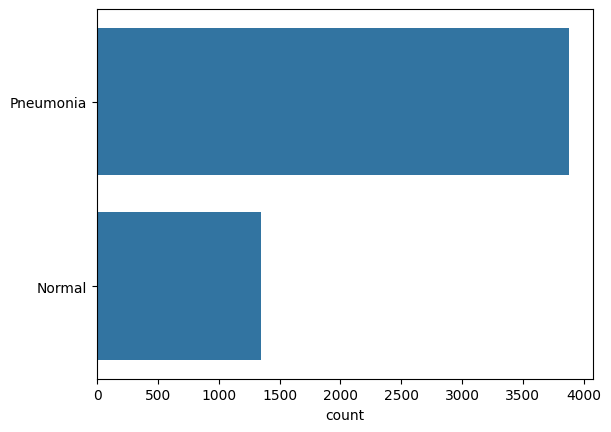

In [8]:
l = []

for i in train:
  if i[1] == 0:
    l.append('Pneumonia')
  else:
    l.append('Normal')

sns.countplot(l)

Text(0.5, 1.0, 'NORMAL')

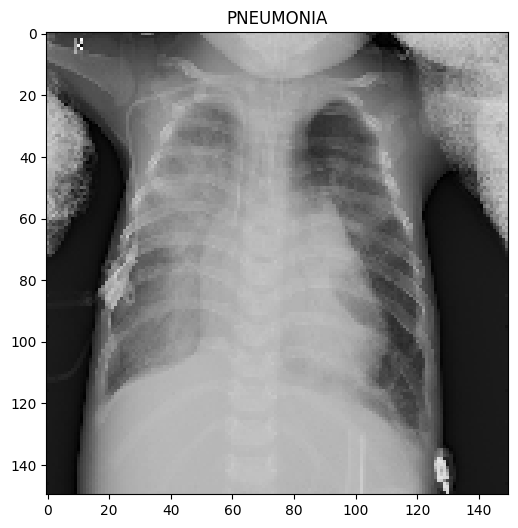

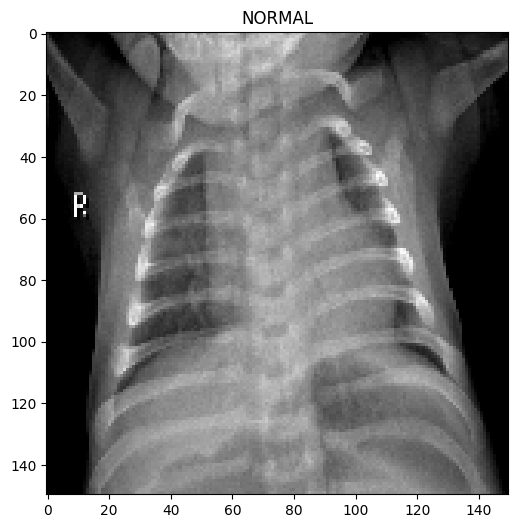

In [9]:
plt.figure(figsize=(6,6))

plt.imshow(train[0][0],cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))

plt.imshow(train[-1][0],cmap='gray')
plt.title(labels[train[-1][1]])


In [10]:
x_train = []
y_train = []
x_test =[]
y_test = []

for feature,label in train:
  x_train.append(feature)
  y_train.append(label)

for feature,label in test:
  x_test.append(feature)
  y_test.append(label)

In [11]:
x_train = np.array(x_train) / 255
x_test = np.array(x_test) / 255

In [12]:
x_train = x_train.reshape(-1,img_resize,img_resize,1)
y_train = np.array(y_train)

x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

In [13]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

In [14]:
model = Sequential()

model.add(Conv2D(32,(3,3), strides=1, padding='same',activation='relu',input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(64,(3,3), strides=1, padding='same',activation='relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(64,(3,3), strides=1, padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(128,(3,3), strides=1, padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Conv2D(256,(3,3), strides=1, padding='same',activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='same'))

model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [15]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=0.000001
)

In [16]:
history = model.fit(x_train,y_train,batch_size=32,
                    epochs=17,
                    validation_data=datagen.flow(x_test,y_test),
                    callbacks=[learning_rate_reduction]
                    )

Epoch 1/17
164/164 ━━━━━━━━━━━━━━━━━━━━ 464s 3s/step - accuracy: 0.9285 - loss: 0.2600 - val_accuracy: 0.6176 - val_loss: 6.4590 - learning_rate: 0.0010
Epoch 2/17
164/164 ━━━━━━━━━━━━━━━━━━━━ 510s 3s/step - accuracy: 0.9687 - loss: 0.0839 - val_accuracy: 0.6176 - val_loss: 8.3201 - learning_rate: 0.0010
Epoch 3/17
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9810 - loss: 0.0551
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
164/164 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.9807 - loss: 0.0562 - val_accuracy: 0.6176 - val_loss: 6.2261 - learning_rate: 0.0010
Epoch 4/17
164/164 ━━━━━━━━━━━━━━━━━━━━ 469s 3s/step - accuracy: 0.9866 - loss: 0.0327 - val_accuracy: 0.6487 - val_loss: 2.5743 - learning_rate: 3.0000e-04
Epoch 5/17
164/164 ━━━━━━━━━━━━━━━━━━━━ 476s 3s/step - accuracy: 0.9918 - loss: 0.0218 - val_accuracy: 0.7729 - val_loss: 0.7490 - learning_rate: 3.0000e-04
Epoch 6/17
164/164 ━━━━━━━━━━━━━━━━━━━━ 509s 3s/step - accuracy: 0.9941 - los

In [17]:
model.evaluate(x_test,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 541ms/step - accuracy: 0.7353 - loss: 1.8735


[1.873496651649475, 0.7352941036224365]

In [18]:
print(f"Loss of the model is {model.evaluate(x_test,y_test)[0]}")
print(f"Accuracy of the model is {model.evaluate(x_test,y_test)[1]*100}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - accuracy: 0.7353 - loss: 1.8735
Loss of the model is 1.873496651649475
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 435ms/step - accuracy: 0.7353 - loss: 1.8735
Accuracy of the model is 73.52941036224365


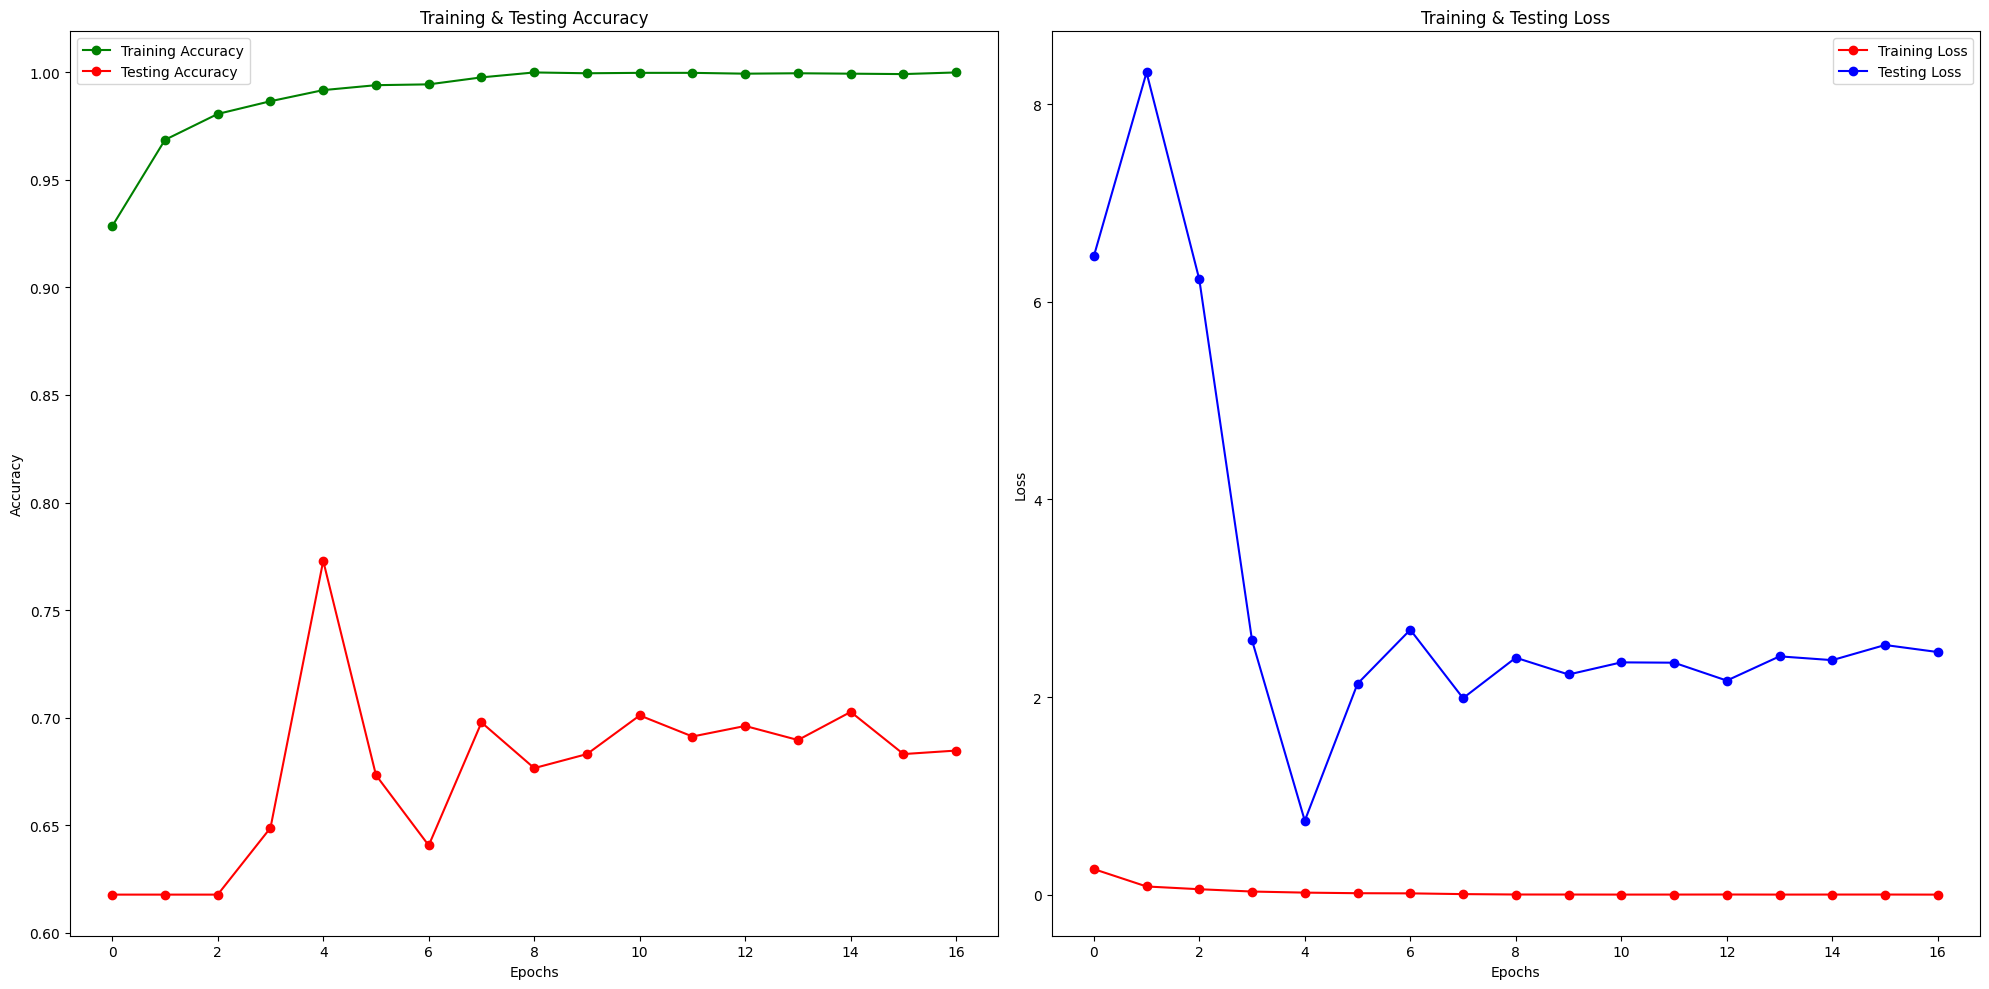

In [19]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

epochs = [i for i in range(len(train_acc))] # Adjusted to match the length of history data
fig, ax = plt.subplots(1,2)

fig.set_size_inches(20,10)

ax[0].plot(epochs,train_acc,'go-',label='Training Accuracy')
ax[0].plot(epochs,test_acc,'ro-',label='Testing Accuracy')
ax[0].set_title('Training & Testing Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

ax[1].plot(epochs,train_loss,'ro-',label='Training Loss')
ax[1].plot(epochs,test_loss,'bo-',label='Testing Loss')
ax[1].set_title('Training & Testing Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [20]:
predictions = (model.predict(x_test) > 0.5).astype("int32")
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 439ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [21]:
print(classification_report(y_test,predictions, target_names=['Pneumonia (Class 0)','Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.70      1.00      0.82       378
   Normal (Class 1)       0.99      0.31      0.47       234

           accuracy                           0.74       612
          macro avg       0.84      0.65      0.65       612
       weighted avg       0.81      0.74      0.69       612



In [22]:
cm = confusion_matrix(y_test,predictions)
cm

array([[377,   1],
       [161,  73]])

In [23]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

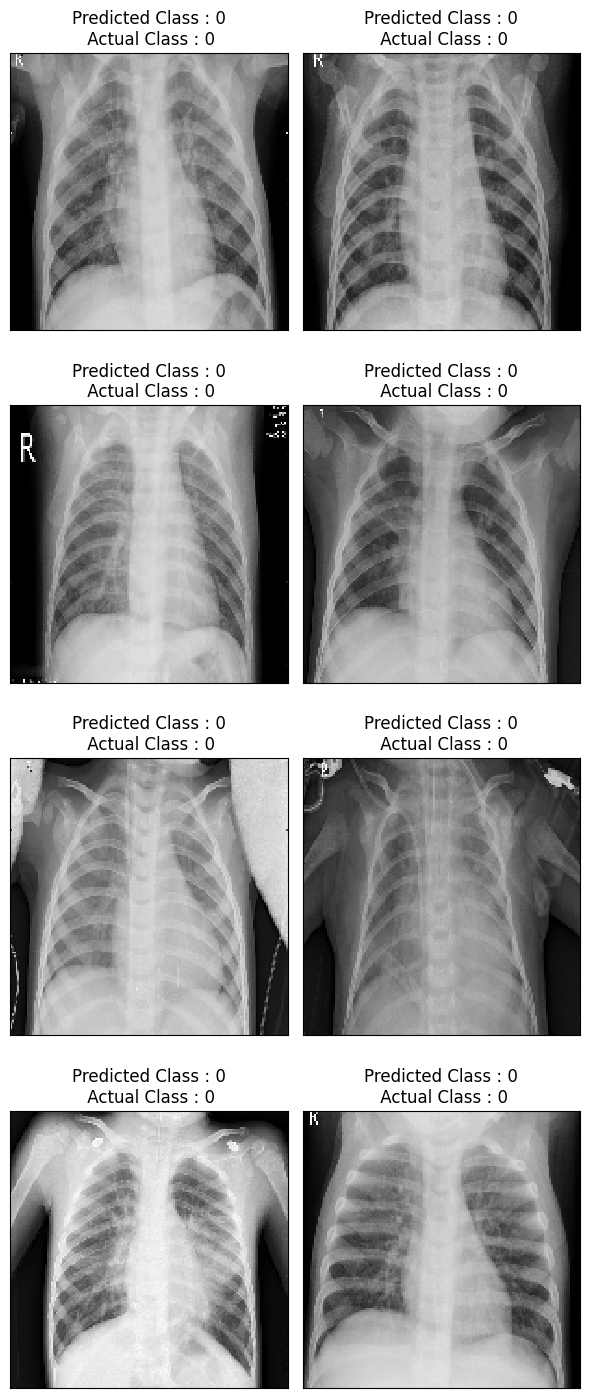

In [24]:
i = 0
plt.figure(figsize=(6,15))
for c in correct[:8]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150),cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\n Actual Class : {y_test[c]}")
  plt.tight_layout()
  i+=1


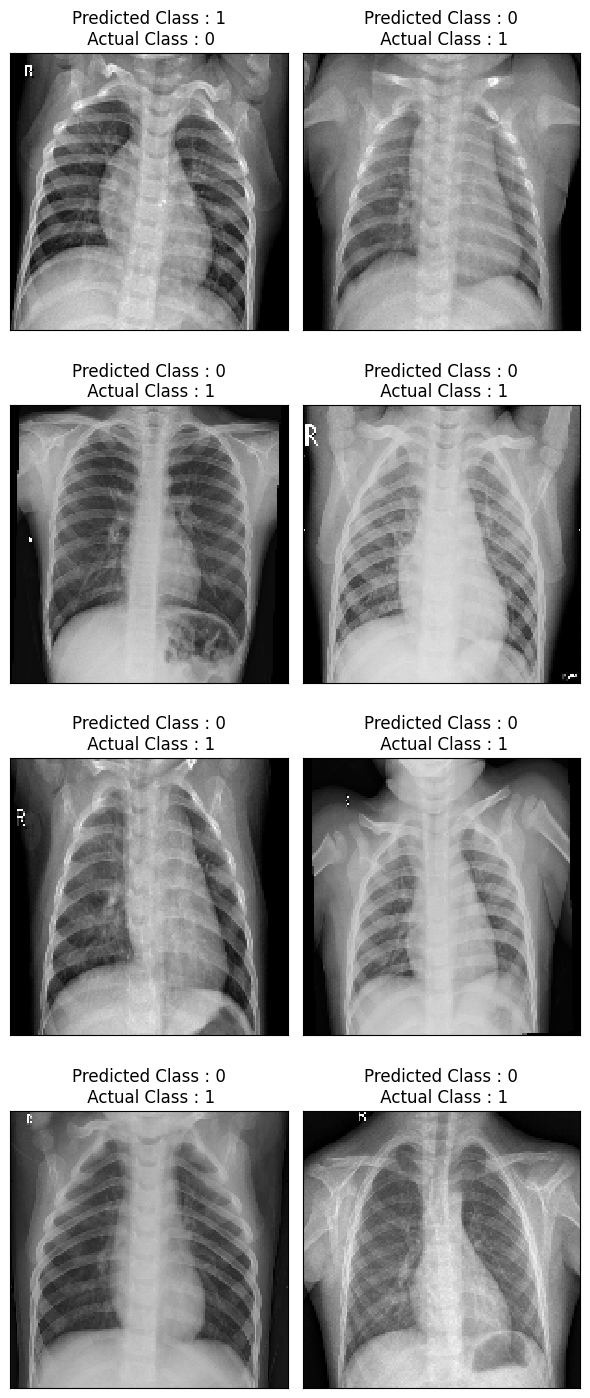

In [25]:
i = 0
plt.figure(figsize=(6,15))
for c in incorrect[:8]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150),cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\n Actual Class : {y_test[c]}")
  plt.tight_layout()
  i+=1
